In [1]:
!pip install -q boto3 tqdm netCDF4 torch scikit-learn seaborn matplotlib pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 96.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 81.8 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import timedelta
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    precision_recall_curve, average_precision_score, roc_auc_score,
    confusion_matrix, classification_report, brier_score_loss, f1_score
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression

import netCDF4

# === Reproducibility ===
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# === Device setup ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# === Station files (4 inland stations, CSV from R2) ===
# After R2 download, files land at {DATA_DIR}/precipitation-nowcasting/weather_stations/...
PRECIP_DIR = f"precipitation-nowcasting"

STATION_FILES = {
    'cer': 'weather_stations/CER_consolid_f15.csv',
    'jun': 'weather_stations/JUN_consolid_f15.csv',
    'merc': 'weather_stations/MERC_consolid_f15.csv',
    'mira': 'weather_stations/MIRA_consolid_f15.csv',
}

# === Column mapping: harmonized name -> list of candidate column names ===
# Multi-candidate lookup handles naming inconsistencies between stations
COLUMN_MAP = {
    'rain_mm': ['Rain_mm_Tot'],
    'temp_c': ['AirTC_Avg'],
    'rh_avg': ['RH_Avg'],
    'rh_max': ['RH_Max'],
    'rh_min': ['RH_Min'],
    'solar_kw': ['SlrkW_Avg'],
    'net_rad_wm2': ['NR_Wm2_Avg'],
    'wind_speed_ms': ['WS_ms_Avg'],
    'wind_dir': ['WindDir'],
    'soil_moisture_1': ['VW_Avg', 'VW'],
    'soil_moisture_2': ['VW_2_Avg', 'VW_2'],
    'soil_moisture_3': ['VW_3_Avg', 'VW_3'],
    'leaf_wetness': ['LWmV_Avg'],
    'leaf_wet_minutes': ['LWMWet_Tot'],
}


def load_station(name, filename):
    """Load a station CSV, harmonize columns, set datetime index."""
    path = f"{PRECIP_DIR}/{filename}"
    print(f"  Loading {name} from {filename}...", end=" ")
    df = pd.read_csv(path)
    print(f"({df.shape[0]:,} rows, {df.shape[1]} cols)")

    # === Parse timestamp (M/D/YYYY H:MM format) ===
    df['TIMESTAMP'] = pd.to_datetime(df['TIMESTAMP'], format='%m/%d/%Y %H:%M')
    df = df.set_index('TIMESTAMP').sort_index()

    # === Multi-candidate column lookup ===
    rename = {}
    for harmonized, candidates in COLUMN_MAP.items():
        for candidate in candidates:
            if candidate in df.columns:
                rename[candidate] = harmonized
                break  # use the first match

    df = df[list(rename.keys())].rename(columns=rename)

    # === Force numeric (some columns loaded as object due to mixed types) ===
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df.attrs['station'] = name
    return df


# === Load all stations ===
print("Loading 4 inland weather stations...")
stations = {}
for name, fname in tqdm(STATION_FILES.items(), desc="Stations"):
    stations[name] = load_station(name, fname)

print(f"\nLoaded {len(stations)} stations.")
for name, df in stations.items():
    print(f"  {name:8s}: {df.index.min().date()} -> {df.index.max().date()}"
          f"  ({df.shape[0]:>8,} rows, {len(df.columns)} cols)")
    missing = [c for c in COLUMN_MAP if c not in df.columns]
    if missing:
        print(f"           Missing variables: {missing}")

Loading 4 inland weather stations...


Stations:   0%|          | 0/4 [00:00<?, ?it/s]

  Loading cer from weather_stations/CER_consolid_f15.csv... (376,763 rows, 46 cols)


Stations:  25%|██▌       | 1/4 [00:06<00:18,  6.22s/it]

  Loading jun from weather_stations/JUN_consolid_f15.csv... (375,325 rows, 54 cols)


...

  Loading merc from weather_stations/MERC_consolid_f15.csv... 

Stations:  75%|███████▌  | 3/4 [00:20<00:06,  6.75s/it]

(375,337 rows, 54 cols)
  Loading mira from weather_stations/MIRA_consolid_f15.csv... (376,771 rows, 54 cols)


Stations: 100%|██████████| 4/4 [00:23<00:00,  5.89s/it]


Loaded 4 stations.
  cer     : 2015-06-07 -> 2026-03-06  ( 376,763 rows, 13 cols)
           Missing variables: ['net_rad_wm2']
  jun     : 2015-06-22 -> 2026-03-06  ( 375,325 rows, 14 cols)
  merc    : 2015-06-22 -> 2026-03-06  ( 375,337 rows, 14 cols)
  mira    : 2015-06-07 -> 2026-03-06  ( 376,771 rows, 14 cols)


Preprocessing

In [4]:
# === Target station for baseline model ===
TARGET_STATION = 'jun'  # El Junco — highest-elevation, most rainfall
STATIONS = list(STATION_FILES.keys())

# === Merge all stations into wide DataFrame ===
# Prefix each station's columns with its abbreviation, then concat on shared time index
print("Merging stations into multi-station DataFrame...")
prefixed = []
for name, stn_df in stations.items():
    renamed = stn_df.add_prefix(f'{name}_')
    prefixed.append(renamed)

df = pd.concat(prefixed, axis=1, sort=True)

# === Drop columns that are entirely NaN (e.g., cer_net_rad_wm2 — CER lacks this sensor) ===
all_nan_cols = [c for c in df.columns if df[c].isnull().all()]
if all_nan_cols:
    print(f"  Dropping {len(all_nan_cols)} entirely-NaN columns: {all_nan_cols}")
    df = df.drop(columns=all_nan_cols)

print(f"Wide DataFrame: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"  Time range: {df.index.min()} -> {df.index.max()}")
print(f"\nMissing data before imputation (showing > 0% only):")
missing = df.isnull().mean() * 100
print(missing[missing > 0].round(1).to_string())

Merging stations into multi-station DataFrame...
  Dropping 5 entirely-NaN columns: ['cer_rh_avg', 'cer_rh_max', 'cer_rh_min', 'merc_leaf_wet_minutes', 'mira_soil_moisture_1']
Wide DataFrame: 376,771 rows x 50 cols
  Time range: 2015-06-07 13:30:00 -> 2026-03-06 06:00:00

Missing data before imputation (showing > 0% only):
cer_rain_mm               5.6
cer_temp_c               11.5
cer_solar_kw              5.6
cer_wind_speed_ms        52.1
cer_wind_dir             39.7
cer_soil_moisture_1       6.3
cer_soil_moisture_2       6.1
cer_soil_moisture_3       6.4
cer_leaf_wetness         88.0
cer_leaf_wet_minutes     31.4
jun_rain_mm               3.1
jun_temp_c               60.2
jun_rh_avg               90.5
jun_rh_max               55.6
jun_rh_min               90.5
jun_solar_kw              3.7
jun_net_rad_wm2          10.3
jun_wind_speed_ms         3.9
jun_wind_dir             17.1
jun_soil_moisture_1       3.1
jun_soil_moisture_2       3.1
jun_soil_moisture_3       3.1
jun_leaf_wetnes

Data imputation

In [5]:
# === Per-station imputation on the wide DataFrame ===

# Listado de variables que tienen correlación entre estaciones
# Agrupamos por tipo para decidir cómo tratarlas
vars_to_impute = [
    'temp_c', 'rh_avg', 'rh_max', 'rh_min',         # Termo-higrométricas
    'solar_kw', 'net_rad_wm2',                      # Radiación
    'soil_moisture_1', 'soil_moisture_2', 'soil_moisture_3'           # Suelo
    'wind_speed_ms'                                 # Viento
]

print("Iniciando imputación espacial entre estaciones...")

for var in vars_to_impute:
    # 1. Identificar las columnas de esta variable en todas las estaciones presentes
    # Ejemplo: 'stn1_temp_c', 'stn2_temp_c', etc.
    cols_existentes = [f"{stn}_{var}" for stn in STATIONS if f"{stn}_{var}" in df.columns]

    if not cols_existentes:
        continue

    # 2. Calcular la media de las estaciones que SÍ tienen dato en cada momento
    # Usamos axis=1 para promediar horizontalmente (espacialmente)
    # skipna=True permite que si 3 fallan, la 4ta salve el dato
    spatial_mean = df[cols_existentes].mean(axis=1)

    # 3. Rellenar los huecos de cada estación usando ese promedio espacial
    for col in cols_existentes:
        null_count = df[col].isnull().sum()
        if null_count > 0:
            df[col] = df[col].fillna(spatial_mean)
            print(f"  > {col}: imputados {null_count:,} nulos usando estaciones vecinas.")

# === CASO ESPECIAL: Variables que no se promedian (Dirección de viento) ===
# Para dirección de viento, usamos el valor de la estación más cercana o un ffill corto
for stn in STATIONS:
    dir_col = f"{stn}_wind_dir"
    if dir_col in df.columns:
        df[dir_col] = df[dir_col].ffill(limit=8) # Máximo 2 horas

# ==========================================================
# 2. LIMPIEZA FINAL (NUEVO: Para eliminar los 6M de nulos)
# ==========================================================
print("\n--- Ejecutando limpieza de nulos residuales (Climatología) ---")

# Relleno por hora: Si todas las estaciones fallaron, usamos el promedio de esa hora
hour_map = df.index.hour
for col in df.columns:
    if df[col].isnull().any():
        # Calculamos la media histórica de esa hora para esa columna
        mean_by_hour = df.groupby(hour_map)[col].transform('mean')
        df[col] = df[col].fillna(mean_by_hour)

# Último recurso: Interpolación lineal para huecos donde no había ni promedios
df = df.interpolate(method='linear').ffill().bfill()

# Asegurar que el índice sea perfecto (15 min) para que el Dataset no salte ventanas
df = df.resample('15min').asfreq().ffill(limit=4)

'''
for stn in STATIONS:
    # Temperature, humidity: interpolate up to 6h (24 steps at 15-min)
    for var in ['temp_c', 'rh_avg', 'rh_max', 'rh_min']:
        col = f'{stn}_{var}'
        if col in df.columns:
            df[col] = df[col].interpolate(method='time', limit=24)

    # Solar / net radiation: interpolate up to 6h
    for var in ['solar_kw', 'net_rad_wm2']:
        col = f'{stn}_{var}'
        if col in df.columns:
            df[col] = df[col].interpolate(method='time', limit=24)

    # Soil moisture: interpolate up to 6h (physically smooth)
    for var in ['soil_moisture_1', 'soil_moisture_2', 'soil_moisture_3']:
        col = f'{stn}_{var}'
        if col in df.columns:
            df[col] = df[col].interpolate(method='time', limit=24)

    # Wind speed: forward-fill short gaps, then interpolate up to 2h
    col = f'{stn}_wind_speed_ms'
    if col in df.columns:
        df[col] = df[col].ffill(limit=4)
        df[col] = df[col].interpolate(method='time', limit=8)

    # Wind direction: forward-fill only (circular — never interpolate)
    col = f'{stn}_wind_dir'
    if col in df.columns:
        df[col] = df[col].ffill(limit=8)

    # Leaf wetness: forward-fill (sensor state change)
    for var in ['leaf_wetness', 'leaf_wet_minutes']:
        col = f'{stn}_{var}'
        if col in df.columns:
            df[col] = df[col].ffill(limit=8)

    # Precipitation: zero-fill + binary rain indicator
    rain_col = f'{stn}_rain_mm'
    if rain_col in df.columns:
        df[f'{stn}_rain_missing'] = df[rain_col].isnull().astype(float)
        df[rain_col] = df[rain_col].fillna(0.0)

# === Global forward/backward fill for remaining short gaps ===
df = df.ffill(limit=96).bfill(limit=96)

# === Fill any remaining NaN with 0 (long sensor outages) ===
still_nan = df.isnull().sum().sum()
if still_nan > 0:
    n_cols_with_nan = (df.isnull().sum() > 0).sum()
    print(f"Filling {still_nan:,} remaining NaN across {n_cols_with_nan} columns with 0 "
          "(long sensor outages)")
df = df.fillna(0.0)'''

# === Defragment DataFrame (avoids PerformanceWarning in feature engineering) ===
df = df.copy()

print(f"Final DataFrame: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"Missing data after imputation: {df.isnull().sum().sum()}")

Iniciando imputación espacial entre estaciones...
  > cer_temp_c: imputados 43,449 nulos usando estaciones vecinas.
  > jun_temp_c: imputados 226,965 nulos usando estaciones vecinas.
  > merc_temp_c: imputados 196,339 nulos usando estaciones vecinas.
  > mira_temp_c: imputados 56,896 nulos usando estaciones vecinas.
  > jun_rh_avg: imputados 341,011 nulos usando estaciones vecinas.
  > merc_rh_avg: imputados 341,163 nulos usando estaciones vecinas.
  > mira_rh_avg: imputados 341,115 nulos usando estaciones vecinas.
  > jun_rh_max: imputados 209,527 nulos usando estaciones vecinas.
  > merc_rh_max: imputados 169,086 nulos usando estaciones vecinas.
  > mira_rh_max: imputados 205,340 nulos usando estaciones vecinas.
  > jun_rh_min: imputados 341,011 nulos usando estaciones vecinas.
  > merc_rh_min: imputados 341,163 nulos usando estaciones vecinas.
  > mira_rh_min: imputados 341,115 nulos usando estaciones vecinas.
  > cer_solar_kw: imputados 21,082 nulos usando estaciones vecinas.
  > j

In [6]:
df.columns

Index(['cer_rain_mm', 'cer_temp_c', 'cer_solar_kw', 'cer_wind_speed_ms',
       'cer_wind_dir', 'cer_soil_moisture_1', 'cer_soil_moisture_2',
       'cer_soil_moisture_3', 'cer_leaf_wetness', 'cer_leaf_wet_minutes',
       'jun_rain_mm', 'jun_temp_c', 'jun_rh_avg', 'jun_rh_max', 'jun_rh_min',
       'jun_solar_kw', 'jun_net_rad_wm2', 'jun_wind_speed_ms', 'jun_wind_dir',
       'jun_soil_moisture_1', 'jun_soil_moisture_2', 'jun_soil_moisture_3',
       'jun_leaf_wetness', 'jun_leaf_wet_minutes', 'merc_rain_mm',
       'merc_temp_c', 'merc_rh_avg', 'merc_rh_max', 'merc_rh_min',
       'merc_solar_kw', 'merc_net_rad_wm2', 'merc_wind_speed_ms',
       'merc_wind_dir', 'merc_soil_moisture_1', 'merc_soil_moisture_2',
       'merc_soil_moisture_3', 'merc_leaf_wetness', 'mira_rain_mm',
       'mira_temp_c', 'mira_rh_avg', 'mira_rh_max', 'mira_rh_min',
       'mira_solar_kw', 'mira_net_rad_wm2', 'mira_wind_speed_ms',
       'mira_wind_dir', 'mira_soil_moisture_2', 'mira_soil_moisture_3',
      

In [7]:
df.columns.size

50

Feature engineering

In [8]:
# === Cyclical time features (shared across stations) ===
df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
df['doy_sin'] = np.sin(2 * np.pi * df.index.dayofyear / 365.25)
df['doy_cos'] = np.cos(2 * np.pi * df.index.dayofyear / 365.25)

# === Per-station derived features ===
for stn in STATIONS:
    # Wind vector decomposition: circular direction -> linear Wx/Wy
    wd_col = f'{stn}_wind_dir'
    ws_col = f'{stn}_wind_speed_ms'
    if wd_col in df.columns and ws_col in df.columns:
        wd_rad = np.deg2rad(df[wd_col])
        df[f'{stn}_wind_x'] = df[ws_col] * np.cos(wd_rad)
        df[f'{stn}_wind_y'] = df[ws_col] * np.sin(wd_rad)

    # Dewpoint approximation (Magnus formula)
    # Td = (237.3 * alpha) / (17.27 - alpha)
    # alpha = (17.27 * T) / (237.3 + T) + ln(RH / 100)
    temp_col = f'{stn}_temp_c'
    rh_col = f'{stn}_rh_avg'
    if temp_col in df.columns and rh_col in df.columns:
        T = df[temp_col]
        RH = df[rh_col].clip(lower=1)  # avoid log(0)
        alpha = (17.27 * T) / (237.3 + T) + np.log(RH / 100)
        df[f'{stn}_dewpoint'] = (237.3 * alpha) / (17.27 - alpha)
        df[f'{stn}_dewpoint_depression'] = T - df[f'{stn}_dewpoint']

    # Soil moisture tendency (3h change) — signals subsurface water movement
    sm_col = f'{stn}_soil_moisture_1'
    if sm_col in df.columns:
        df[f'{stn}_soil_moist_tend_3h'] = df[sm_col].diff(periods=12)

    # Rolling statistics: accumulated rain, temp/wind/humidity trends
    for window, wlabel in [(4, '1h'), (12, '3h'), (24, '6h')]:
        rain_col = f'{stn}_rain_mm'
        if rain_col in df.columns:
            df[f'{stn}_rain_sum_{wlabel}'] = df[rain_col].rolling(window, min_periods=1).sum()

        if temp_col in df.columns:
            df[f'{stn}_temp_mean_{wlabel}'] = df[temp_col].rolling(window, min_periods=1).mean()
            df[f'{stn}_temp_std_{wlabel}'] = df[temp_col].rolling(window, min_periods=1).std()

        if ws_col in df.columns:
            df[f'{stn}_wind_mean_{wlabel}'] = df[ws_col].rolling(window, min_periods=1).mean()

        if rh_col in df.columns:
            df[f'{stn}_rh_mean_{wlabel}'] = df[rh_col].rolling(window, min_periods=1).mean()

print(f"Features after engineering: {len(df.columns)} columns")
print(f"  Shared time features: 4")
print(f"  Per-station columns: ~{(len(df.columns) - 4) // len(STATIONS)} each")

Features after engineering: 128 columns
  Shared time features: 4
  Per-station columns: ~31 each


In [9]:
# === Precipitation labels (per-station) ===
HORIZONS = {'1h': 4, '3h': 12, '6h': 24} #{'3h': 12, '6h': 24, '12h': 48}  # steps at 15-min resolution

# Forward-looking accumulated rainfall for each station and horizon
for stn in STATIONS:
    rain_col = f'{stn}_rain_mm'
    for label, steps in HORIZONS.items():
        df[f'rain_future_{label}_{stn}'] = (
            df[rain_col]
            .rolling(steps, min_periods=1)
            .sum()
            .shift(-steps)
        )

# === Compute thresholds from training period (target station, to avoid leakage) ===
train_mask = df.index < '2023-01-01'
print(f"Precipitation accumulation statistics ({TARGET_STATION}, training period, wet > 0):")

thresholds = {}
for label, steps in HORIZONS.items():
    col = f'rain_future_{label}_{TARGET_STATION}'
    wet = df.loc[train_mask, col]
    wet = wet[wet > 0]
    p95 = wet.quantile(0.95)
    p99 = wet.quantile(0.99)
    thresholds[label] = max(p95, 2.0)
    print(f"  {label}: mean={wet.mean():.2f}mm, p50={wet.median():.2f}mm, "
          f"p95={p95:.2f}mm, p99={p99:.2f}mm -> threshold={thresholds[label]:.2f}mm")

for stn in STATIONS:
    for label in HORIZONS:
        col = f'rain_future_{label}_{stn}'
        # Definimos condiciones
        conditions = [
            (df[col] <= 0),                          # Clase 0: No Rain
            (df[col] > 0) & (df[col] < thresholds[label]), # Clase 1: Light Rain
            (df[col] >= thresholds[label])           # Clase 2: Heavy Rain
        ]
        choices = [0, 1, 2]
        df[f'rain_class_{label}_{stn}'] = np.select(conditions, choices, default=np.nan)


# === Default targets (from TARGET_STATION) for the baseline model ===
# Actualizado para usar 'rain_class' en lugar de 'heavy_rain'
for label in HORIZONS:
    source_col = f'rain_class_{label}_{TARGET_STATION}'
    target_col = f'rain_class_{label}'
    if source_col in df.columns:
        df[target_col] = df[source_col]
    else:
        print(f"⚠️ Error: No se encontró {source_col}. Verifica el paso de creación de labels.")

# === Temperature anomaly (target station) ===
# (Esta parte se mantiene igual porque son features, no labels)
temp_col = f'{TARGET_STATION}_temp_c'
df['day_of_year'] = df.index.dayofyear
daily_clim = df.loc[train_mask].groupby('day_of_year')[temp_col].agg(['mean', 'std'])
daily_clim['mean_smooth'] = daily_clim['mean'].rolling(15, center=True, min_periods=5).mean()
daily_clim['std_smooth'] = daily_clim['std'].rolling(15, center=True, min_periods=5).mean()
daily_clim = daily_clim.bfill().ffill()

df['temp_clim_mean'] = df['day_of_year'].map(daily_clim['mean_smooth'])
df['temp_clim_std'] = df['day_of_year'].map(daily_clim['std_smooth'])
df['temp_anomaly'] = (df[temp_col] - df['temp_clim_mean']) / df['temp_clim_std']
df['temp_extreme'] = (df['temp_anomaly'].abs() > 2).astype(float)

# === Label balance (MODIFICADO PARA 3 CLASES) ===
print(f"\nLabel balance (full dataset, target station: {TARGET_STATION}):")
for label in HORIZONS:
    col = f'rain_class_{label}'
    if col in df.columns:
        # Contamos la frecuencia de cada clase (0, 1, 2)
        counts = df[col].value_counts(normalize=True).sort_index() * 100
        n_total = df[col].count()

        print(f"  {col} (N={n_total}):")
        print(f"    - [0] No Rain:    {counts.get(0.0, 0):.2f}%")
        print(f"    - [1] Light Rain: {counts.get(1.0, 0):.2f}%")
        print(f"    - [2] Heavy Rain: {counts.get(2.0, 0):.2f}%")
    else:
        print(f"  ❌ Columna {col} no encontrada.")

print(f"  temp_extreme: {df['temp_extreme'].mean():.3%} positive ({df['temp_extreme'].sum():.0f} events)")

# === Show per-station label comparison (MODIFICADO PARA 3 CLASES) ===
print(f"\nPer-station 3h heavy rain rates (Class 2):")
for stn in STATIONS:
    col = f'rain_class_3h_{stn}'
    if col in df.columns:
        # Calculamos el % de veces que es Clase 2 (Heavy Rain)
        heavy_rate = (df[col] == 2.0).mean()
        n_heavy = (df[col] == 2.0).sum()
        print(f"  {stn}: {heavy_rate:.3%} heavy rain events ({n_heavy:.0f} events)")

Precipitation accumulation statistics (jun, training period, wet > 0):
  1h: mean=0.72mm, p50=0.25mm, p95=2.29mm, p99=6.60mm -> threshold=2.29mm
  3h: mean=1.37mm, p50=0.51mm, p95=4.83mm, p99=13.46mm -> threshold=4.83mm
  6h: mean=2.10mm, p50=0.88mm, p95=7.62mm, p99=20.83mm -> threshold=7.62mm

Label balance (full dataset, target station: jun):
  rain_class_1h (N=376767):
    - [0] No Rain:    76.08%
    - [1] Light Rain: 22.58%
    - [2] Heavy Rain: 1.34%
  rain_class_3h (N=376759):
    - [0] No Rain:    62.29%
    - [1] Light Rain: 35.60%
    - [2] Heavy Rain: 2.11%
  rain_class_6h (N=376747):
    - [0] No Rain:    50.63%
    - [1] Light Rain: 46.59%
    - [2] Heavy Rain: 2.79%
  temp_extreme: 10.649% positive (40121 events)

Per-station 3h heavy rain rates (Class 2):
  cer: 1.305% heavy rain events (4916 events)
  jun: 2.110% heavy rain events (7949 events)
  merc: 0.919% heavy rain events (3461 events)
  mira: 1.060% heavy rain events (3993 events)


In [10]:
df

,cer_rain_mm,cer_temp_c,cer_solar_kw,cer_wind_speed_ms,cer_wind_dir,cer_soil_moisture_1,cer_soil_moisture_2,cer_soil_moisture_3,cer_leaf_wetness,cer_leaf_wet_minutes,...,rain_class_3h_mira,rain_class_6h_mira,rain_class_1h,rain_class_3h,rain_class_6h,day_of_year,temp_clim_mean,temp_clim_std,temp_anomaly,temp_extreme
TIMESTAMP,,,,,,,,,,,,,,,,,,,,,
2015-06-07 13:30:00,0.056548,25.296667,0.719333,3.837776,176.655496,0.425523,0.567085,0.645717,295.857338,0.538926,...,0.0,0.0,1.0,1.0,1.0,158,19.491789,1.673430,3.468850,1.0
2015-06-07 13:45:00,0.056548,25.730000,0.846667,3.837776,176.655496,0.425523,0.567085,0.645717,295.857338,0.538926,...,0.0,0.0,1.0,1.0,1.0,158,19.491789,1.673430,3.727799,1.0
2015-06-07 14:00:00,0.044566,26.053333,0.723667,3.787829,175.917684,0.426096,0.567261,0.645632,293.649662,0.490245,...,0.0,0.0,1.0,1.0,1.0,158,19.491789,1.673430,3.921015,1.0
2015-06-07 14:15:00,0.044566,26.483333,0.765000,3.787829,175.917684,0.426096,0.567261,0.645632,293.649662,0.490245,...,0.0,0.0,1.0,1.0,1.0,158,19.491789,1.673430,4.177972,1.0
2015-06-07 14:30:00,0.044566,26.140000,0.689000,3.787829,175.917684,0.426096,0.567261,0.645632,293.649662,0.490245,...,0.0,0.0,1.0,1.0,1.0,158,19.491789,1.673430,3.972805,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-06 05:00:00,0.000000,23.182448,0.000000,1.231389,141.002200,0.379057,0.594867,0.713073,360.113184,1.833055,...,NaN,NaN,0.0,NaN,NaN,65,23.046869,2.080421,-0.919229,0.0
2026-03-06 05:15:00,0.000000,23.330538,0.000000,0.591389,136.417867,0.378838,0.594641,0.713112,360.113184,1.833055,...,NaN,NaN,NaN,NaN,NaN,65,23.046869,2.080421,-0.940295,0.0
2026-03-06 05:30:00,0.000000,23.269256,0.000000,0.003611,125.785300,0.378725,0.594464,0.713116,360.113184,1.833055,...,NaN,NaN,NaN,NaN,NaN,65,23.046869,2.080421,-0.932700,0.0


Data splitting

In [11]:
# === Define split boundaries ===
TRAIN_END = pd.Timestamp('2023-01-01')
VAL_END = pd.Timestamp('2024-07-01')
EMBARGO_STEPS = 48  # 12 hours at 15-min resolution

# === Drop temporary columns, keep features + labels ===
# Eliminamos las columnas auxiliares pero mantenemos nuestras nuevas 'rain_class'
drop_cols = [c for c in df.columns if c.startswith('rain_future_')]
# Opcional: si ya no necesitas las columnas por estación y solo quieres la del TARGET_STATION:
# drop_cols += [c for c in df.columns if 'rain_class' in c and not c.endswith(TARGET_STATION) and c.count('_') > 2]
drop_cols += ['day_of_year', 'temp_clim_mean', 'temp_clim_std']
df_final = df.drop(columns=[c for c in drop_cols if c in df.columns])

# === Split by timestamp with Embargo ===
train_df = df_final[df_final.index < TRAIN_END].copy()

# Embargo: saltamos 12h después del límite de entrenamiento
val_start = TRAIN_END + timedelta(hours=12)
val_df = df_final[(df_final.index >= val_start) & (df_final.index < VAL_END)].copy()

# Embargo: saltamos 12h después del límite de validación
test_start = VAL_END + timedelta(hours=12)
test_df = df_final[df_final.index >= test_start].copy()

print(f"✅ Train: {train_df.index.min().date()} → {train_df.index.max().date()} ({len(train_df):,} rows)")
print(f"✅ Val:   {val_df.index.min().date()} → {val_df.index.max().date()} ({len(val_df):,} rows)")
print(f"✅ Test:  {test_df.index.min().date()} → {test_df.index.max().date()} ({len(test_df):,} rows)")

# === Check label balance in each split (Actualizado para 3 clases) ===
print("\n📊 Distribución de Clases por Split:")
for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    for label in HORIZONS:
        col = f'rain_class_{label}'
        if col in split_df.columns:
            counts = split_df[col].value_counts(normalize=True).sort_index() * 100
            n_heavy = (split_df[col] == 2.0).sum()
            print(f"  {split_name} {label}:")
            print(f"    - No Rain (0):    {counts.get(0.0, 0):.1f}%")
            print(f"    - Light Rain (1): {counts.get(1.0, 0):.1f}%")
            print(f"    - Heavy Rain (2): {counts.get(2.0, 0):.1f}% ({n_heavy:.0f} eventos)")
        else:
            print(f"  ⚠️ Columna {col} no encontrada en {split_name}")

✅ Train: 2015-06-07 → 2022-12-31 (265,386 rows)
✅ Val:   2023-01-01 → 2024-06-30 (52,464 rows)
✅ Test:  2024-07-01 → 2026-03-06 (58,825 rows)

📊 Distribución de Clases por Split:
  Train 1h:
    - No Rain (0):    75.6%
    - Light Rain (1): 23.1%
    - Heavy Rain (2): 1.3% (3376 eventos)
  Train 3h:
    - No Rain (0):    61.6%
    - Light Rain (1): 36.5%
    - Heavy Rain (2): 1.9% (5128 eventos)
  Train 6h:
    - No Rain (0):    49.9%
    - Light Rain (1): 47.6%
    - Heavy Rain (2): 2.5% (6663 eventos)
  Val 1h:
    - No Rain (0):    76.2%
    - Light Rain (1): 21.5%
    - Heavy Rain (2): 2.3% (1187 eventos)
  Val 3h:
    - No Rain (0):    65.4%
    - Light Rain (1): 30.8%
    - Heavy Rain (2): 3.8% (1974 eventos)
  Val 6h:
    - No Rain (0):    55.9%
    - Light Rain (1): 39.0%
    - Heavy Rain (2): 5.1% (2680 eventos)
  Test 1h:
    - No Rain (0):    78.1%
    - Light Rain (1): 21.1%
    - Heavy Rain (2): 0.8% (499 eventos)
  Test 3h:
    - No Rain (0):    62.6%
    - Light Rain (1)

Data normalization

In [12]:
# === Define feature columns (everything except labels and intermediates) ===
# Actualizamos LABEL_COLS para que coincida con tus nuevas etiquetas multiclase
LABEL_COLS = [f'rain_class_{h}' for h in HORIZONS]
for stn in STATIONS:
    LABEL_COLS += [f'rain_class_{h}_{stn}' for h in HORIZONS]

# Incluimos las métricas de temperatura que creaste antes
LABEL_COLS += ['temp_extreme', 'temp_anomaly']

# Las FEATURES son todas las columnas que NO están en la lista de etiquetas
FEATURE_COLS = [c for c in train_df.columns if c not in LABEL_COLS]

print(f"✅ Feature columns ({len(FEATURE_COLS)}):")
for i, c in enumerate(FEATURE_COLS[:15]):
    print(f"   {i:3d}. {c}")
if len(FEATURE_COLS) > 15:
    print(f"   ... and {len(FEATURE_COLS) - 15} more")

# === Compute train statistics ===
# Es vital calcular esto SOLO en el set de entrenamiento para evitar data leakage
train_mean = train_df[FEATURE_COLS].mean()
train_std = train_df[FEATURE_COLS].std()

# Evitamos división por cero si un sensor se quedó pegado en un valor constante
train_std = train_std.replace(0, 1)

# === Normalize all splits (Z-score normalization) ===
# Aplicamos la media y desviación del entrenamiento a los 3 sets
for name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    split_df[FEATURE_COLS] = (split_df[FEATURE_COLS] - train_mean) / train_std

print(f"\n🚀 Normalization complete (fitted on training data only).")
print(f"   Mean: {train_mean.mean():.2f}, Std: {train_std.mean():.2f} (avg across features)")

✅ Feature columns (128):
     0. cer_rain_mm
     1. cer_temp_c
     2. cer_solar_kw
     3. cer_wind_speed_ms
     4. cer_wind_dir
     5. cer_soil_moisture_1
     6. cer_soil_moisture_2
     7. cer_soil_moisture_3
     8. cer_leaf_wetness
     9. cer_leaf_wet_minutes
    10. jun_rain_mm
    11. jun_temp_c
    12. jun_rh_avg
    13. jun_rh_max
    14. jun_rh_min
   ... and 113 more

🚀 Normalization complete (fitted on training data only).
   Mean: 35.16, Std: 10.75 (avg across features)


Pytorch dataset and data loader

In [13]:
LOOKBACK = 96  # 24 hours of 15-min data
TARGET_COL = "rain_class_3h"

class WeatherDataset(Dataset):
    """Sliding window dataset for weather time series classification (Multiclass: 0, 1, 2)."""

    def __init__(self, df, feature_cols, target_col, lookback=96):
        self.lookback = lookback
        self.target_col = target_col

        # === 1. Mantener el DataFrame COMPLETO para la lógica de ventanas ===
        # No borramos filas con NaN aquí porque romperíamos la secuencia temporal.
        # En su lugar, usaremos una máscara para saber qué ventanas son válidas.

        self.features = df[feature_cols].values.astype(np.float32)
        self.labels = df[target_col].values.astype(np.int64)
        self.timestamps = df.index

        # Máscara de filas que NO tienen NaNs (usada para validar la ventana)
        row_is_clean = df[feature_cols + [target_col]].notna().all(axis=1).values

        # === 2. Construcción de ventanas (Sliding Window) ===
        valid_indices_list = []
        expected_delta = pd.Timedelta(minutes=15)

        # Usamos tqdm para ver el progreso
        for i in tqdm(range(lookback, len(self.features)),
                      desc=f"Building windows ({target_col})", leave=False):

            # A. Verificamos que la ventana actual NO tenga NaNs
            if not row_is_clean[i - lookback : i + 1].all():
                continue

            # B. Verificamos continuidad temporal (que no falten 15 min en medio)
            window_times = self.timestamps[i - lookback : i + 1]
            # Comparar el tiempo inicial y final vs el número de pasos
            # (Más rápido que calcular todas las diferencias)
            if (window_times[-1] - window_times[0]) == (lookback * expected_delta):
                valid_indices_list.append(i)

        # === CAMBIO CLAVE: Asegurar tipo entero para indexación ===
        self.valid_indices = np.array(valid_indices_list, dtype=np.int64)

        # === 3. Reporte de Clases ===
        n_total = len(self.valid_indices)
        if n_total > 0:
            # Extraer etiquetas de los índices que realmente usaremos
            actual_labels = self.labels[self.valid_indices]
            counts = pd.Series(actual_labels).value_counts(normalize=True).sort_index() * 100

            print(f"\n--- Resumen {target_col} ---")
            print(f"  Valid windows: {n_total:,}")
            dist_str = ", ".join([f"Clase {k}: {v:.1f}%" for k, v in counts.items()])
            print(f"  Distribución: {dist_str}")
        else:
            print(f"\n⚠️ ADVERTENCIA: No se encontraron ventanas válidas para {target_col}")

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        # Forzamos a que el índice sea un entero de Python para evitar el IndexError
        if torch.is_tensor(idx):
            idx = idx.item()

        # Obtenemos el índice real del array de características
        i = int(self.valid_indices[idx])

        # x: Ventana de datos (lookback pasos anteriores)
        x = self.features[i - self.lookback : i]
        # y: Etiqueta en el momento actual (i)
        y = self.labels[i]

        return torch.from_numpy(x), torch.tensor(y, dtype=torch.long)

# === Creación de datasets ===
# Asumiendo que train_df, val_df, test_df y FEATURE_COLS ya están definidos
print("Iniciando creación de datasets...")
train_ds = WeatherDataset(train_df, FEATURE_COLS, TARGET_COL, LOOKBACK)
val_ds   = WeatherDataset(val_df, FEATURE_COLS, TARGET_COL, LOOKBACK)
test_ds  = WeatherDataset(test_df, FEATURE_COLS, TARGET_COL, LOOKBACK)

Iniciando creación de datasets...



--- Resumen rain_class_3h ---
  Valid windows: 265,278
  Distribución: Clase 0: 61.6%, Clase 1: 36.4%, Clase 2: 1.9%



--- Resumen rain_class_3h ---
  Valid windows: 52,368
  Distribución: Clase 0: 65.4%, Clase 1: 30.9%, Clase 2: 3.8%



--- Resumen rain_class_3h ---
  Valid windows: 58,717
  Distribución: Clase 0: 62.6%, Clase 1: 36.0%, Clase 2: 1.4%


In [14]:
from torch.utils.data import WeightedRandomSampler

# --- Configuración del Sampler para el Dataset de Entrenamiento ---

# 1. Obtenemos las etiquetas de todas las ventanas válidas del set de entrenamiento
# Nota: usamos train_ds.valid_indices para mapear solo las ventanas que el modelo usará
train_labels = train_ds.labels[train_ds.valid_indices]

# 2. Contamos cuántas muestras hay de cada clase (0, 1, 2)
class_counts = np.bincount(train_labels) # Resultado: [N_clase0, N_clase1, N_clase2]

# 3. Calculamos el peso de la clase (inverso de la frecuencia)
# A menor cantidad de muestras, mayor peso para la clase
#class_weights = 1.0 / class_counts
class_weights = 1.0 / np.sqrt(class_counts)

# 4. Asignamos a CADA muestra su peso correspondiente según su etiqueta
weights_per_sample = class_weights[train_labels]

# 5. Creamos el Sampler
# num_samples=len(weights_per_sample) asegura que una "época" tenga el mismo tamaño original
# replacement=True es obligatorio cuando usamos pesos
sampler = WeightedRandomSampler(
    weights=weights_per_sample,
    num_samples=len(weights_per_sample),
    replacement=True
)

print(f"Sampler configurado. Pesos de clase: {class_weights}")

Sampler configurado. Pesos de clase: [0.00247341 0.00321592 0.01396452]


In [15]:
# === DataLoaders (Se mantienen igual, pero ahora entregan etiquetas Long) ===
BATCH_SIZE = 256

# Entrenamiento: USA el sampler y NO usa shuffle
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,          # <--- CAMBIO CLAVE
    drop_last=True
)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nBatches listos: train={len(train_loader)}, val={len(val_loader)}, test={len(test_loader)}")


Batches listos: train=1036, val=205, test=230


Model definitions

In [16]:
import torch.nn as nn

class RecurrentClassifier(nn.Module):
    """Architecture for RNN/LSTM/GRU multiclass (3 classes) classifiers."""

    def __init__(self, input_dim, hidden_dim=16, num_layers=2, dropout=0.5,
                 rnn_type='lstm', num_classes=3): # Agregamos num_classes
        super().__init__()
        self.rnn_type = rnn_type

        # === Select recurrent cell ===
        rnn_cls = {'rnn': nn.RNN, 'lstm': nn.LSTM, 'gru': nn.GRU}[rnn_type]
        self.rnn = rnn_cls(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True,
        )

        # === Classification head (MODIFICADO) ===
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes), # Salida de 3 neuronas
        )

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        output, _ = self.rnn(x)

        # Usamos el estado oculto final (último paso de tiempo)
        last_hidden = output[:, -1, :]  # (batch, hidden_dim)

        # Obtenemos los logits (batch, num_classes)
        logits = self.classifier(last_hidden)

        # IMPORTANTE: En PyTorch, si usas nn.CrossEntropyLoss,
        # NO debes aplicar Softmax aquí, la función de pérdida ya lo incluye.
        return logits


# === Instantiate all 3 models (3 clases) ===
n_features = len(FEATURE_COLS)
num_classes = 3 # No rain, Light rain, Heavy rain

models = {
    'RNN': RecurrentClassifier(n_features, num_classes=num_classes, rnn_type='rnn').to(device),
    'LSTM': RecurrentClassifier(n_features, num_classes=num_classes, rnn_type='lstm').to(device),
    'GRU': RecurrentClassifier(n_features, num_classes=num_classes, rnn_type='gru').to(device),
}

for name, model in models.items():
    n_params = sum(p.numel() for p in model.parameters())
    print(f"{name}: {n_params:,} parameters")

RNN: 2,931 parameters
LSTM: 11,571 parameters
GRU: 8,691 parameters


Model training

In [17]:
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=1.5, reduction='mean'):
        """
        alpha: Tensor de pesos por clase (equivalente a class_weights)
        gamma: Factor de enfoque. 2.0 es el estándar.
        """
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss) # Probabilidad de la clase correcta
        focal_loss = ((1 - pt) ** self.gamma * ce_loss)

        if self.reduction == 'mean':
            return focal_loss.mean()
        return focal_loss.sum()

In [18]:
def compute_class_weight(dataset):
    """Compute positive class weight from dataset labels."""
    labels = dataset.labels[dataset.valid_indices]
    pos_rate = labels.mean()
    if pos_rate == 0 or pos_rate == 1:
        return 1.0
    weight = (1 - pos_rate) / pos_rate
    return min(weight, 20.0)  # cap at 20x — higher values cause overconfident predictions


def train_model(model, train_loader, val_loader, class_weights, lr, max_epochs, patience, model_name):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)

    # === CORRECTO: Instanciar la clase primero ===
    # Asegúrate de que class_weights sea un tensor de PyTorch
    #criterion = nn.CrossEntropyLoss(weight=class_weights)
    criterion = FocalLoss(alpha=class_weights, gamma=1.5)

    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(max_epochs):
        # --- FASE DE ENTRENAMIENTO ---
        model.train()
        train_loss = 0
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(x_batch) # Shape: [256, 3]

            # Aquí es donde se usa el criterion instanciado
            loss = criterion(outputs, y_batch)

            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # --- FASE DE VALIDACIÓN ---
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x_val, y_val in val_loader:
                x_val, y_val = x_val.to(device), y_val.to(device)
                val_outputs = model(x_val)
                v_loss = criterion(val_outputs, y_val)
                val_loss += v_loss.item()

        # Guardar historial
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        scheduler.step(avg_val_loss)
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)

        print(f"Epoch {epoch+1}/{max_epochs} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

        # Early Stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            # Save the weights for the best model
            checkpoint_path = f"best_model_{model_name}.pth"
            torch.save(model.state_dict(), checkpoint_path)
            print(f"--- Saved model: {checkpoint_path} (Val Loss: {avg_val_loss:.4f}) ---")

        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stopping!")
                break

    return history

Evaluation functions

In [19]:
def get_predictions(model, loader):
    model.eval()
    all_probs = []
    all_labels = []
    device = next(model.parameters()).device

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x)

            # Aplicamos Softmax para obtener la probabilidad de las 3 clases
            probs = torch.softmax(logits, dim=1)

            # Pasamos a CPU y NumPy
            all_probs.append(probs.cpu().numpy())
            all_labels.append(y.numpy())

    # UNIÓN CORRECTA: vstack mantiene las columnas (N, 3)
    final_probs = np.vstack(all_probs)
    final_labels = np.concatenate(all_labels)

    return final_probs, final_labels

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def evaluate_model(y_true, y_pred, y_probs, name):
    """
    Función para evaluar la clasificación multiclase (0, 1, 2).
    """
    print(f"\n" + "-"*30)
    print(f"MÉTRICAS PARA: {name}")
    print("-"*30)

    # Reporte detallado por clase
    target_names = ['No Rain (0)', 'Light (1)', 'Heavy (2)']
    report = classification_report(y_true, y_pred, target_names=target_names)
    print(report)

    # Cálculo de Accuracy simple
    acc = accuracy_score(y_true, y_pred)

    # Retornamos un diccionario con lo básico para la tabla comparativa final
    return {
        'model': name,
        'accuracy': acc
    }


def persistence_baseline(dataset, horizon_steps):
    """Persistence baseline: predict same state as current time.

    For binary classification: if it's raining now, predict rain in N hours.
    """
    labels = dataset.labels[dataset.valid_indices]
    # The "current" rain state is the last timestep's rain value
    # Since labels are at the end of the window, persistence = current label
    # This is a simplification — true persistence uses the current observation
    return labels, labels

def plot_evaluation(y_true, y_prob, model_name='Model'):
    """
    Plot PR curve, reliability, and distribution for Heavy Rain (Class 2).
    y_prob: Expected shape (N, 3) from your Softmax output.
    """
    # === PREPARACIÓN MULTICLASE ===
    # Nos enfocamos en la Clase 2 (Heavy Rain)
    TARGET_CLASS = 2
    y_true_binary = (y_true == TARGET_CLASS).astype(int)
    y_prob_class = y_prob[:, TARGET_CLASS] # Probabilidades solo de la clase 2

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # === 1. PR Curve (Enfocada en Heavy Rain) ===
    ax = axes[0]
    # Si no hay eventos de clase 2 en el test, evitamos error
    if y_true_binary.sum() > 0:
        prec, rec, _ = precision_recall_curve(y_true_binary, y_prob_class)
        pr_auc = average_precision_score(y_true_binary, y_prob_class)
        ax.plot(rec, prec, label=f'{model_name} (AP={pr_auc:.3f})', color='darkblue')

        baseline = y_true_binary.mean()
        ax.axhline(baseline, color='gray', linestyle='--', label=f'Baseline ({baseline:.3f})')

    ax.set_xlabel('Recall (Capacidad de detección)')
    ax.set_ylabel('Precision (Fiabilidad de alerta)')
    ax.set_title(f'P-R Curve: Heavy Rain (Clase {TARGET_CLASS})')
    ax.legend()
    ax.grid(alpha=0.3)

    # === 2. Reliability Diagram (¿Es honesto el modelo?) ===
    ax = axes[1]
    if y_true_binary.sum() > 0:
        # Usamos strategy='uniform' porque 'quantile' falla si hay muchos ceros
        prob_true, prob_pred = calibration_curve(y_true_binary, y_prob_class, n_bins=10)
        ax.plot(prob_pred, prob_true, 's-', label=model_name, color='darkorange')

    ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
    ax.set_xlabel('Probabilidad Predicha')
    ax.set_ylabel('Frecuencia Observada Real')
    ax.set_title('Diagrama de Fiabilidad')
    ax.legend()
    ax.grid(alpha=0.3)

    # === 3. Score Distribution (Separación de clases) ===
    ax = axes[2]
    # Histograma de probabilidades para cuando NO es clase 2 vs cuando SÍ lo es
    ax.hist(y_prob_class[y_true != TARGET_CLASS], bins=30, alpha=0.4,
            label='Otras Clases (0, 1)', density=True, color='gray')
    ax.hist(y_prob_class[y_true == TARGET_CLASS], bins=30, alpha=0.6,
            label='Heavy Rain (2)', density=True, color='red')

    ax.set_xlabel('Probabilidad asignada a Clase 2')
    ax.set_ylabel('Densidad')
    ax.set_title('Distribución de Scores')
    ax.legend()

    plt.suptitle(f'{model_name} — Evaluación de Eventos Críticos (Clase 2)', fontsize=15, y=1.05)
    plt.tight_layout()
    plt.show()

In [20]:
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, model_name='Model'):
    """
    Dibuja una matriz de confusión para las 3 clases de lluvia.
    """
    # 1. Calcular la matriz
    cm = confusion_matrix(y_true, y_pred)

    # 2. Configurar nombres de las clases
    class_names = ['No Rain (0)', 'Light (1)', 'Heavy (2)']

    # 3. Graficar
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,     # Muestra los números
        fmt='d',        # Formato de números enteros
        cmap='Blues',   # Color azul
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(f'Matriz de Confusión: {model_name}')
    plt.xlabel('Predicción del Modelo')
    plt.ylabel('Realidad (Sensores)')
    plt.show()

In [21]:
# === 1. Compute class weights for 3 classes ===
# Ahora necesitamos un peso para cada clase (No Rain, Light, Heavy)
def get_multiclass_weights(dataset):
    # Obtenemos las etiquetas de los índices válidos
    y = dataset.labels[dataset.valid_indices]
    counts = np.bincount(y)
    total = len(y)
    # Peso = Total / (n_clases * conteo_clase)
    weights = total / (len(counts) * counts)
    return torch.tensor(weights, dtype=torch.float32).to(device)

cweights = get_multiclass_weights(train_ds)
print(f"Class weights: No Rain={cweights[0]:.1f}, Light={cweights[1]:.1f}, Heavy={cweights[2]:.1f}")

Class weights: No Rain=0.5, Light=0.9, Heavy=17.2


In [22]:
# === 2. Train all models ===
histories = {}
for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"   Training {name}")
    print(f"{'='*50}")

    # IMPORTANTE: Dentro de train_model debes usar nn.CrossEntropyLoss(weight=class_weights)
    histories[name] = train_model(
        model,
        train_loader,
        val_loader,
        class_weights=cweights, # CAMBIADO: pos_weight (escalar) -> class_weights (vector)
        lr=1e-4, #1e-3
        max_epochs=50,
        patience=8,
        model_name=name,
    )

# === Save checkpoints ===
CHECKPOINT_DIR = "checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

for name, model in models.items():
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"{name.lower()}_rain_class_3h.pt")
    torch.save({
        'model_state_dict': model.state_dict(),
        'rnn_type': name.lower(),
        'input_dim': n_features,
        'hidden_dim': 32,
        'num_layers': 3,
        'dropout': 0.5,
        'target': TARGET_COL,
        'lookback': LOOKBACK,
    }, ckpt_path)
    print(f"  Saved {name} checkpoint → {ckpt_path}")


   Training RNN
Epoch 1/50 - Train Loss: 1.4444 - Val Loss: 1.2219
--- Saved model: best_model_RNN.pth (Val Loss: 1.2219) ---
Epoch 2/50 - Train Loss: 0.8701 - Val Loss: 1.0324
--- Saved model: best_model_RNN.pth (Val Loss: 1.0324) ---
Epoch 3/50 - Train Loss: 0.7549 - Val Loss: 0.8929
--- Saved model: best_model_RNN.pth (Val Loss: 0.8929) ---
Epoch 4/50 - Train Loss: 0.7002 - Val Loss: 0.8553
--- Saved model: best_model_RNN.pth (Val Loss: 0.8553) ---
Epoch 5/50 - Train Loss: 0.6713 - Val Loss: 0.8597
Epoch 6/50 - Train Loss: 0.6453 - Val Loss: 0.8829
Epoch 7/50 - Train Loss: 0.6302 - Val Loss: 0.8638
Epoch 8/50 - Train Loss: 0.6161 - Val Loss: 0.8864
Epoch 9/50 - Train Loss: 0.6072 - Val Loss: 0.8804
Epoch 10/50 - Train Loss: 0.5971 - Val Loss: 0.8769
Epoch 11/50 - Train Loss: 0.6066 - Val Loss: 0.8856
Epoch 12/50 - Train Loss: 0.6056 - Val Loss: 0.8805
Early stopping!

   Training LSTM
Epoch 1/50 - Train Loss: 1.1181 - Val Loss: 0.9202
--- Saved model: best_model_LSTM.pth (Val Loss:

Training curves

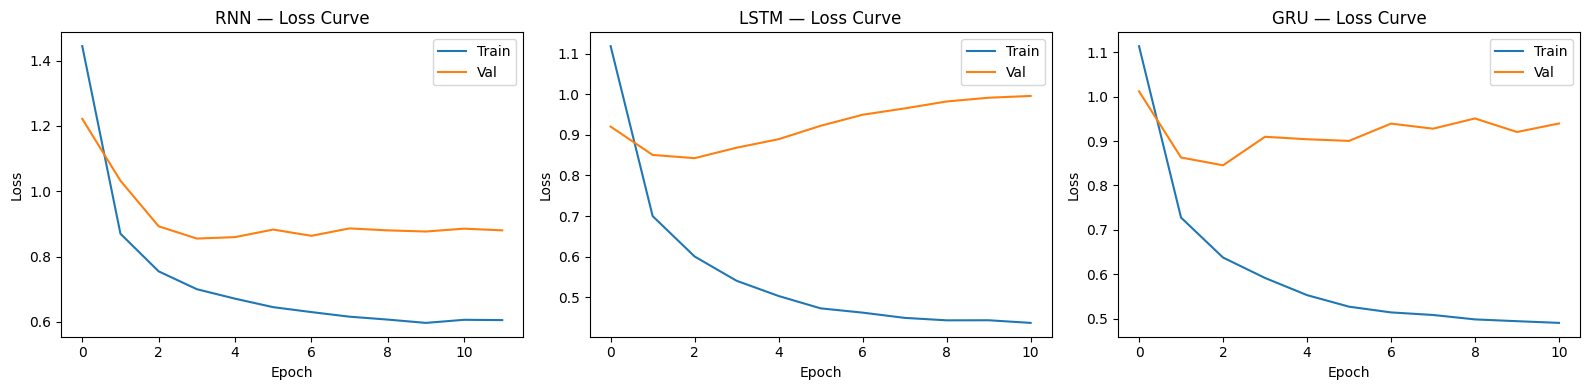

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, hist) in zip(axes, histories.items()):
    ax.plot(hist['train_loss'], label='Train')
    ax.plot(hist['val_loss'], label='Val')
    ax.set_title(f'{name} — Loss Curve')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
plt.tight_layout()
plt.show()

Test set evaluation


Evaluando modelo: RNN...


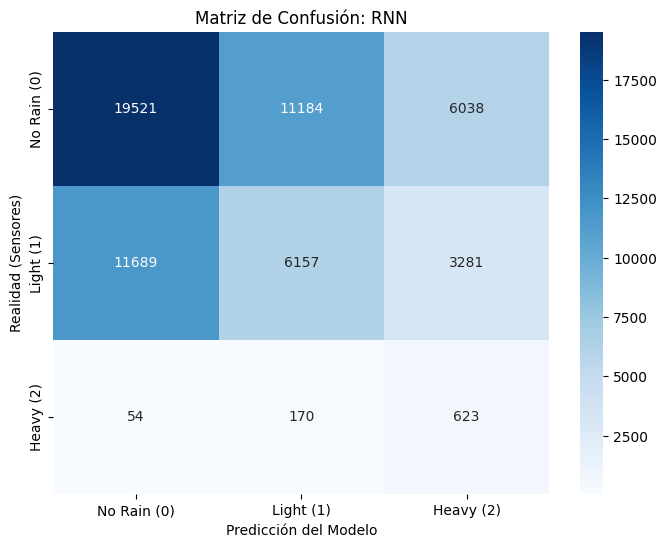


------------------------------
MÉTRICAS PARA: RNN
------------------------------
              precision    recall  f1-score   support

 No Rain (0)       0.62      0.53      0.57     36743
   Light (1)       0.35      0.29      0.32     21127
   Heavy (2)       0.06      0.74      0.12       847

    accuracy                           0.45     58717
   macro avg       0.35      0.52      0.34     58717
weighted avg       0.52      0.45      0.48     58717

1
1


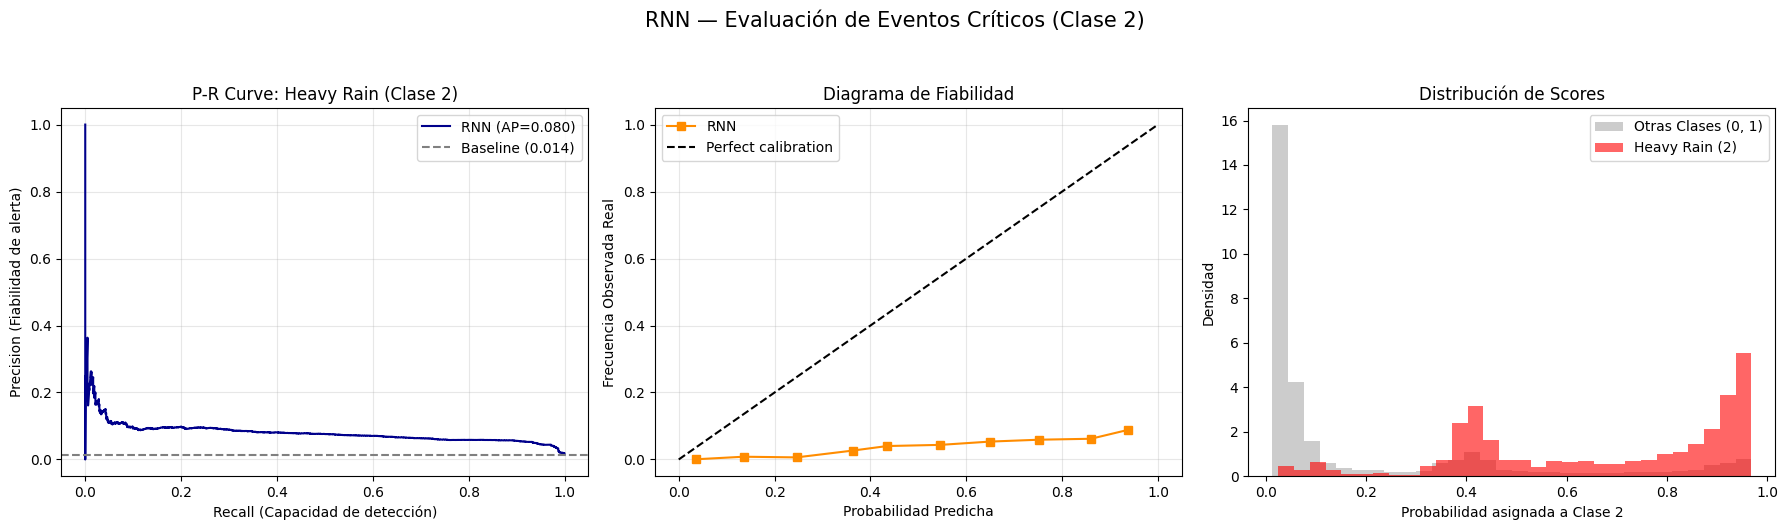


Evaluando modelo: LSTM...


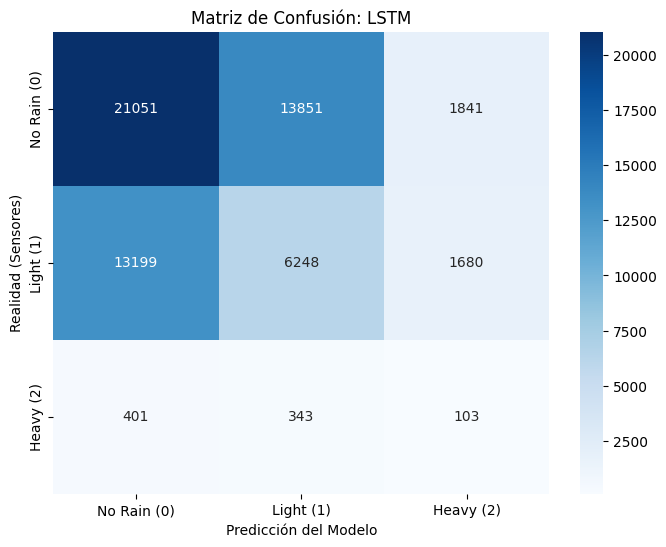


------------------------------
MÉTRICAS PARA: LSTM
------------------------------
              precision    recall  f1-score   support

 No Rain (0)       0.61      0.57      0.59     36743
   Light (1)       0.31      0.30      0.30     21127
   Heavy (2)       0.03      0.12      0.05       847

    accuracy                           0.47     58717
   macro avg       0.31      0.33      0.31     58717
weighted avg       0.49      0.47      0.48     58717

1
1


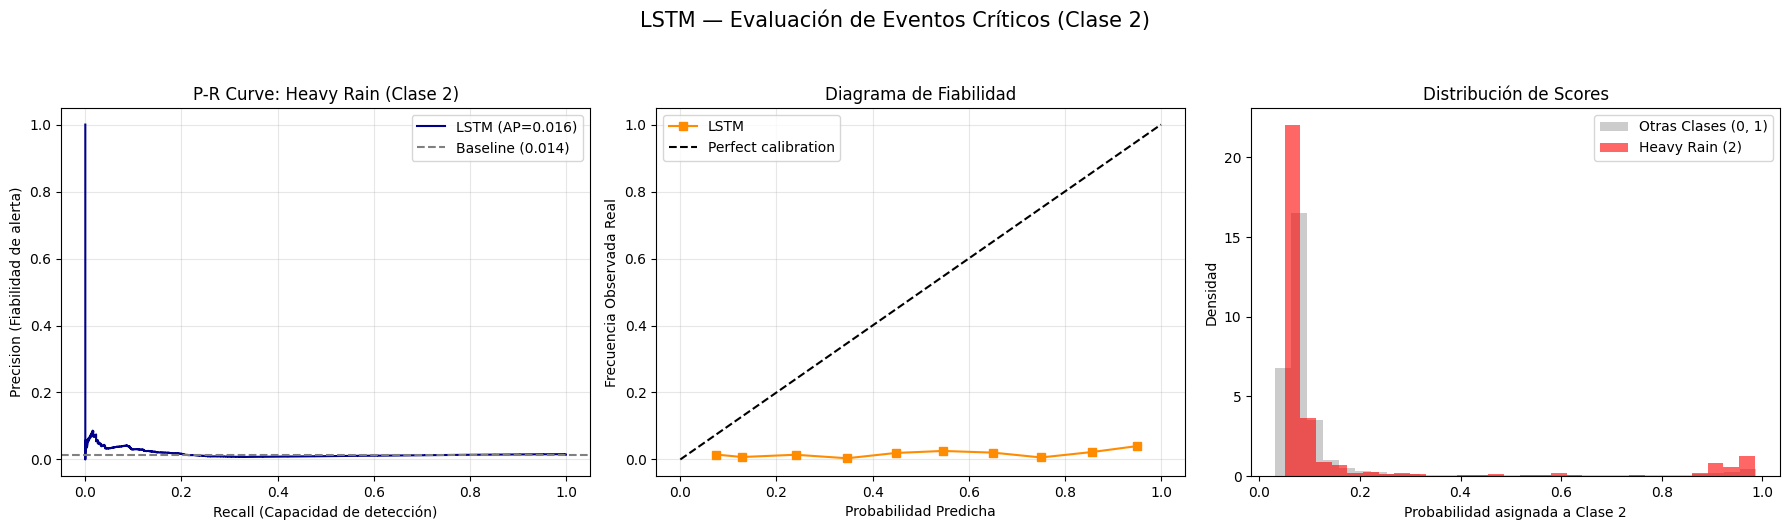


Evaluando modelo: GRU...


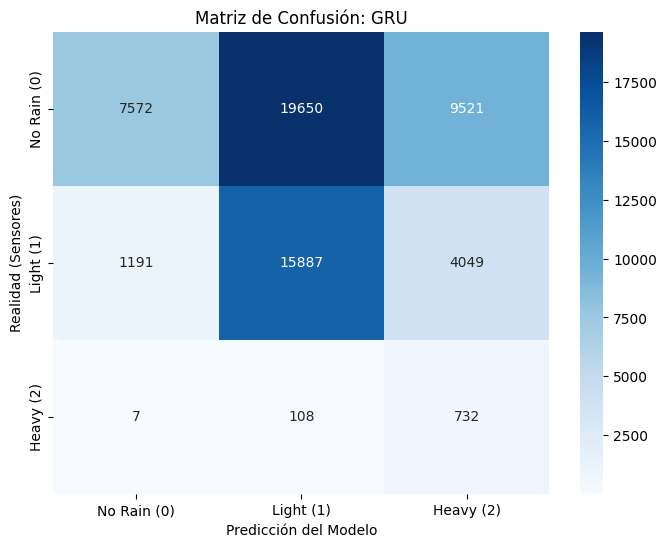


------------------------------
MÉTRICAS PARA: GRU
------------------------------
              precision    recall  f1-score   support

 No Rain (0)       0.86      0.21      0.33     36743
   Light (1)       0.45      0.75      0.56     21127
   Heavy (2)       0.05      0.86      0.10       847

    accuracy                           0.41     58717
   macro avg       0.45      0.61      0.33     58717
weighted avg       0.70      0.41      0.41     58717

1
1


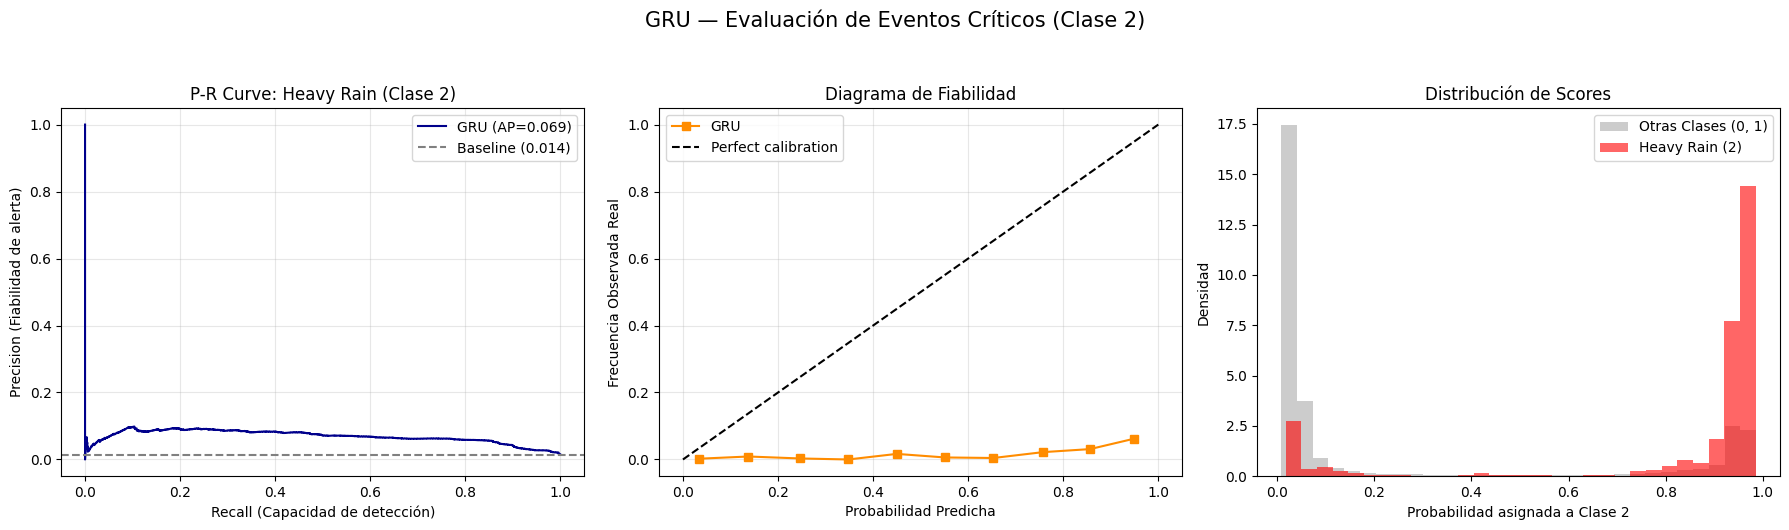

In [24]:
results = []

for name, model in models.items():
    print(f"\n" + "="*50)
    print(f"Evaluando modelo: {name}...")

    # 1. Obtener predicciones
    test_probs, test_labels = get_predictions(model, test_loader)

    # 2. Obtener la clase final (0, 1 o 2)
    test_preds = np.argmax(test_probs, axis=1)


    plot_confusion_matrix(test_labels, test_preds, model_name=name)


    # 3. Evaluación de métricas (Eliminamos conflictos de nombres)
    # Pasamos los argumentos de forma explícita
    metrics = evaluate_model(
        y_true=test_labels,
        y_pred=test_preds,
        y_probs=test_probs,
        name=name  # Cambié model_name por name para evitar el conflicto
    )
    results.append(metrics)

    print(test_labels.ndim)
    print(test_preds.ndim)
    #print(test_labels)

    # 4. Visualización
    plot_evaluation(test_labels, test_probs, model_name=name)

Results comparison

In [25]:
results_df = pd.DataFrame(results)
'''
display_cols = ['model', 'PR-AUC', 'ROC-AUC', 'BSS', 'CSI', 'POD', 'FAR', 'F1',
                'threshold', 'N_events']
print("\n" + "="*80)
print("  RESULTS: Heavy Precipitation Nowcasting (3h Horizon) — Multi-Station (Junco target)")
print("="*80)
print(results_df[display_cols].to_string(index=False, float_format='%.3f'))

# === Highlight best model ===
best_idx = results_df['PR-AUC'].idxmax()
print(f"\nBest model by PR-AUC: {results_df.loc[best_idx, 'model']} "
      f"(PR-AUC = {results_df.loc[best_idx, 'PR-AUC']:.3f})")'''

'\ndisplay_cols = [\'model\', \'PR-AUC\', \'ROC-AUC\', \'BSS\', \'CSI\', \'POD\', \'FAR\', \'F1\',\n                \'threshold\', \'N_events\']\nprint("\n" + "="*80)\nprint("  RESULTS: Heavy Precipitation Nowcasting (3h Horizon) — Multi-Station (Junco target)")\nprint("="*80)\nprint(results_df[display_cols].to_string(index=False, float_format=\'%.3f\'))\n\n# === Highlight best model ===\nbest_idx = results_df[\'PR-AUC\'].idxmax()\nprint(f"\nBest model by PR-AUC: {results_df.loc[best_idx, \'model\']} "\n      f"(PR-AUC = {results_df.loc[best_idx, \'PR-AUC\']:.3f})")'

Generate files

In [26]:
df_final.columns

Index(['cer_rain_mm', 'cer_temp_c', 'cer_solar_kw', 'cer_wind_speed_ms',
       'cer_wind_dir', 'cer_soil_moisture_1', 'cer_soil_moisture_2',
       'cer_soil_moisture_3', 'cer_leaf_wetness', 'cer_leaf_wet_minutes',
       ...
       'rain_class_3h_merc', 'rain_class_6h_merc', 'rain_class_1h_mira',
       'rain_class_3h_mira', 'rain_class_6h_mira', 'rain_class_1h',
       'rain_class_3h', 'rain_class_6h', 'temp_anomaly', 'temp_extreme'],
      dtype='object', length=145)

In [27]:
test_preds = np.argmax(test_probs, axis=1)
test_preds

array([0, 0, 0, ..., 2, 2, 2])

In [28]:
test_loader

In [29]:
import pandas as pd

def generate_submission_csv(test_loader, model, horizon_name):
    """
    Genera el archivo CSV con el formato requerido.
    horizon_name: '1h', '3h' o '6h'
    """
    model.eval()
    data_list = []
    device = next(model.parameters()).device

    with torch.no_grad():
        for batch in test_loader:
            # Extraemos lo necesario. Nota: Tu dataset debe devolver estos metadatos.
            # Si tu loader solo devuelve (x, y), deberás pasar los metadatos aparte.
            inputs, labels, timestamps, station_ids, obs_precip = batch

            inputs = inputs.to(device)
            logits = model(inputs)
            probs = torch.softmax(logits, dim=1)

            # Obtenemos la clase predicha y su probabilidad específica
            pred_classes = torch.argmax(probs, dim=1)
            # Extraemos la probabilidad de la clase elegida
            pred_probs = probs.gather(1, pred_classes.unsqueeze(1)).squeeze()

            # Guardamos cada fila
            for i in range(len(labels)):
                data_list.append({
                    'timestamp': timestamps[i],       # Debe estar en ISO 8601
                    'station_id': station_ids[i],
                    'pred_class': pred_classes[i].item(),
                    'pred_prob': round(pred_probs[i].item(), 4),
                    'obs_class': labels[i].item(),
                    'obs_precip_mm': obs_precip[i].item()
                })

    # Crear DataFrame y exportar
    df = pd.DataFrame(data_list)
    filename = f"submission_{horizon_name}.csv"
    df.to_csv(filename, index=False)
    print(f"✅ Archivo {filename} generado con {len(df)} filas.")
    return df

In [30]:
import pickle

# Definimos la ruta para los archivos pickle
PICKLE_DIR = "models_pkl"
os.makedirs(PICKLE_DIR, exist_ok=True)

for name, model in models.items():
    pkl_path = os.path.join(PICKLE_DIR, f"{name.lower()}_model.pkl")

    # Creamos un diccionario con el estado del modelo y metadatos
    model_data = {
        'model_state_dict': model.state_dict(),
        'params': {
            'input_dim': n_features,
            'hidden_dim': 16, # Asegúrate que coincida con tu clase RecurrentClassifier
            'num_layers': 2,
            'num_classes': 3,
            'rnn_type': name.lower()
        },
        'feature_cols': FEATURE_COLS # Es útil guardar qué columnas usaste
    }

    # Guardar usando pickle
    with open(pkl_path, 'wb') as f:
        pickle.dump(model_data, f)

    print(f"✅ Archivo Pickle generado: {pkl_path}")

✅ Archivo Pickle generado: models_pkl/rnn_model.pkl
✅ Archivo Pickle generado: models_pkl/lstm_model.pkl
✅ Archivo Pickle generado: models_pkl/gru_model.pkl
